
<font size = "5"> **Day 1: [Atomic Resolution STEM and Machine Learning](../MLSTEM2026.ipynb)** </font>


<hr style="height:1px;border-top:4px solid #FF8200" />


[Download](https://github.com/gduscher/MLSTEM2026/raw/refs/heads/main/Day%201/10AM_AberrationCorrection.ipynb)

[![OpenInColab](https://colab.research.google.com/assets/colab-badge.svg)](
   https://colab.research.google.com/github/gduscher/MLSTEM2025/blob/main/Day%201/10AM_AberrationCorrection.ipynb)
   


# Aberration Correction 

part of the workshop of 

<font size = "5"> **[Machine Learning in Transmission Electron Microscopy](../_MLSTEM.ipynb)**</font>


**Day1: Aberrations and Atomic Resolution STEM,**
<table style="margin-right:auto;margin-left:0px">
  <tr>
    <td>Gerd Duscher </td>
    <td>Sergei Kalinin</td>
  </tr>
  <tr>
    <td colspan="2"><center>Microscopy Facilities</td> 
  </tr>
  
  <tr>
    <td colspan="2"><center>Materials Science & Engineering</td>
    <td></td>
  </tr>
  <tr>
    <td colspan="2"><center>Institute of Advanced Materials & Manufacturing</td>
  </tr>
  <tr>
    <td colspan="2"><center> The University of Tennessee, Knoxville</center> </td>
  </tr>
</table>
        
**May 2026**

Contributer to Notebook: Austin Houston

## Import packages for figures and 
First we load the code to make figures from pyTEMlib
### Check Installed Packages



In [ ]:
import sys
import importlib.metadata
def test_package(package_name):
    """Test if package exists and returns version or -1"""
    try:
        version = importlib.metadata.version(package_name)
    except importlib.metadata.PackageNotFoundError:
        version = '-1'
    return version

if test_package('pyTEMlib') < '0.2026.6.0':
    print('installing pyTEMlib')
    !{sys.executable} -m pip install --upgrade pyTEMlib -q
print('done')

installing pyTEMlib

  Using cached pytemlib-0.2025.9.1-py3-none-any.whl.metadata (3.6 kB)
  Using cached ase-3.26.0-py3-none-any.whl.metadata (4.1 kB)
  Using cached pyNSID-0.0.7.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached sidpy-0.12.8-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached SciFiReaders-0.12.0-py2.py3-none-any.whl.metadata (3.2 kB)
  Using cached pyUSID-0.0.12-py2.py3-none-any.whl.metadata (2.4 kB)
  Using cached distributed-2025.9.1-py3-none-any.whl.metadata (3.4 kB)
Using cached pytemlib-0.2025.9.1-py3-none-any.whl (1.2 MB)
Using cached pyNSID-0.0.7.2-py2.py3-none-any.whl (12 kB)
Using cached SciFiReaders-0.12.0-py2.py3-none-any.whl (96 kB)
Using cached sidpy-0.12.8-py2.py3-none-any.whl (112 kB)
Using cached distributed-2025.9.1-py3-none-any.whl (1.0 MB)
Using cached ase-3.26.0-py3-none-any.whl (2.9 MB)
Using cached pyUSID-0.0.12-py2.py3-none-any.whl (69 kB)

   ---------------------------------------- 0/7 [distributed]
   ---------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\gduscher\\AppData\\Local\\anaconda3\\envs\\p3_10\\Lib\\site-packages\\ase\\calculators\\lammps\\inputwriter.py'
Consider using the `--user` option or check the permissions.



### Load necessary packages
We load a few very basic for computer access, numeric and plotting.

The communication is done with the packages:
- tango for communication
- tile or data transfer

pyTEMlib is used for microscope relevant analysis

In [1]:
%matplotlib widget
import os
import json
import time

import matplotlib.pylab as plt
import numpy  as np
import ipywidgets as widgets

import tango
import tiled
from tiled.client import from_uri

import pyTEMlib

print(f"pyTEMlib version: {pyTEMlib.__version__}")


ModuleNotFoundError: No module named 'entrypoints'

In [6]:
# import tiled.client


tiled.__version__

'0.2.12'

## Connection to our microscope

We connect to pyTangoServer at the Microscope
### Connect Database server

In [4]:
DB_HOST = "10.46.217.241"
DB_PORT = 9094

os.environ["TANGO_HOST"] = f"{DB_HOST}:{DB_PORT}"

server_names = ['stage', 'scan', 'eds', 'camera', 'data', 'microscope', 'corrector']

for name in server_names:
    device_name = f"asyncroscopy/{name}/default"
    proxy = tango.DeviceProxy(device_name)
    proxy.ping()
    print(device_name, proxy.state())

asyncroscopy/stage/default ON
asyncroscopy/scan/default ON
asyncroscopy/eds/default ON
asyncroscopy/camera/default ON
asyncroscopy/data/default ON


DevFailed: DevFailed[
    DevError[
        desc = device asyncroscopy/microscope/default not defined in the database !
        origin = DataBase::ImportDevice()
        reason = DB_DeviceNotDefined
        severity = ERR
    ],
    DevError[
        desc = Cannot execute command
        origin = class CORBA::Any *__cdecl PyCmd::execute(class Tango::DeviceImpl *,const class CORBA::Any &) at (C:\gitlab-runner\builds\ehTiiTbyF\4\tango-controls\pytango\ext\server\command.cpp:87)
        reason = PyDs_UnexpectedFailure
        severity = ERR
    ],
    DevError[
        desc = Failed to execute command_inout on device sys/database/2, command DbImportDevice
        origin = class Tango::DeviceData __cdecl Tango::Connection::command_inout(const class std::basic_string<char,struct std::char_traits<char>,class std::allocator<char> > &,const class Tango::DeviceData &) at (C:\gitlab-runner\builds\4xDp-9MBR\0\tango-controls\cppTango\src\client\devapi_base.cpp:2029)
        reason = API_CommandFai

### Connect Devices

In [8]:
scan = tango.DeviceProxy("asyncroscopy/scan/default")
microscope = tango.DeviceProxy("asyncroscopy/instrument/default")
data = tango.DeviceProxy("asyncroscopy/data/default")
corrector_proxy = tango.DeviceProxy("asyncroscopy/corrector/default")

# Backward-compatible aliases used by the workflow cells below.
mic_proxy = microscope
microscope_proxy = microscope

for proxy in (scan, microscope, data, corrector_proxy):
    proxy.set_timeout_millis(120_000)

print("scan      :", scan.state())
print("microscope:", microscope.state())
print("data      :", data.state())
print("corrector :", corrector_proxy.state())


scan      : ON
microscope: ON
data      : ON
corrector : ON


### Open column valve
If everything is okay we can open the column valve

In [45]:
microscope.vacuum.column_valves.open()

### Data Server with Tiled
#### Get Tiled data server parameters

In [15]:
config = json.loads(data.get_config())
config

{'host': '10.46.217.241',
 'port': 9091,
 'uri': 'http://10.46.217.241:9091',
 'save_path': 'outputs/tiled_acquisitions',
 'tiled_server': 'yes',
 'tiled_server_status': 'running; registered path',
 'tiled_server_serving': 'outputs/tiled_acquisitions'}

#### Intitialize Tiled Server


In [ ]:

client = from_uri(config.get("uri"))
print("Tiled keys:", list(client))

ModuleNotFoundError: No module named 'entrypoints'

In [ ]:
TILED_HOST = "10.46.217.241"
TILED_PORT = 9091
save_path = "D:/microscopedata/tiled/ahoust17/2026_05_22_AtomFab/"

data.host = TILED_HOST
data.port = TILED_PORT
data.save_path = save_path

if str(data.tiled_server).lower() != "yes":
    print("Tiled server is not responding; starting it from the DATA device...")
    config = json.loads(data.start_tiled_server())
else:
    print("Tiled server is already running.")
    config = json.loads(data.get_config())

print(json.dumps(config, indent=2))

client = tiled.from_uri(config.get("uri", f"http://{TILED_HOST}:{TILED_PORT}"))
print("Tiled keys:", list(client))

StagePosition(x=23.35938, y=-11.592474, z=-83.64411, a=5.381)


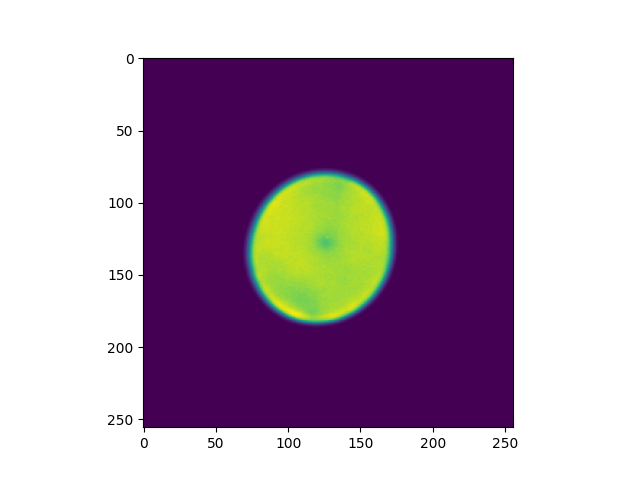

In [46]:
microscope.specimen.stage.relative_move([0,0, 0e-6])
print(microscope.specimen.stage.position*1e6)
image = microscope.acquisition.acquire_camera_image("Flucam", 1024, .02);
plt.figure()
plt.imshow(image.data[384:640, 384:640])

## Focus with Sample Height

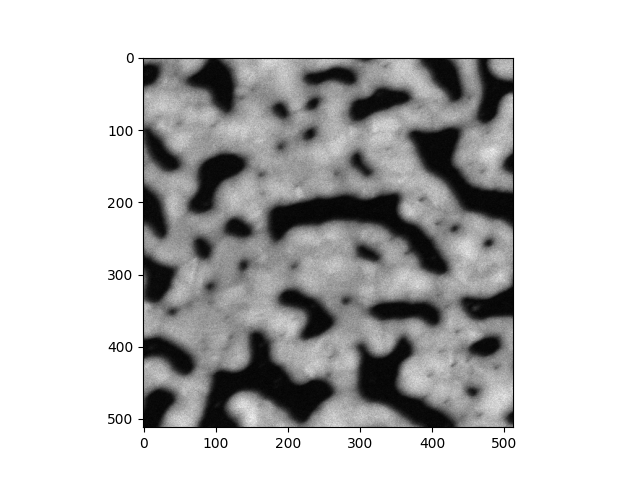

In [25]:
#microscope.specimen.stage.relative_move([0, .1*1e-6, 0*1e-6])
#microscope.optics.defocus = -0e-9
microscope.optics.scan_field_of_view  = .17*1e-6
haadf_image = microscope.acquisition.acquire_stem_image(DetectorType.HAADF, 512, 4e-6)# haadf is pixel wise
fig = plt.figure()
im =  plt.imshow(haadf_image.data, cmap='gray')



## Aberration Correction

Here we are using the tableau function of the CEOS SCORR software.

- tabtype can be "Fast", "Standard", "Enhanced"
- angle is in mili-radian
- We want the first orders from this defocus=C1=C$_{1,0}$, astigmatismus A1,B2, A2

### Correcting 1st and 2nd orders

In [15]:
microscope.optics.unblank()
microscope.optics.scan_field_of_view  = 348*1e-9

tableau_result_12 = ceos_acquisition.run_tableau(tab_type="Fast", angle=1)
def carth2polar(z):
    return np.linalg.norm(z), np.degrees(np.arctan2(z[1], z[0]))
    
for key in ['C1', 'A1', 'B2', 'A2']:
    amplitude , angle = carth2polar(tableau_result_12['aberrations'][key])                                         
    print(f" {key}: {amplitude*1e9:.2f}nm {angle:.2f}deg")
print(f" WD: {np.linalg.norm(tableau_result_12['aberrations']['WD'])*1e3:.3f}mrad ")

 C1: 7.40nm 180.00deg
 A1: 2.56nm -43.79deg
 B2: 15.11nm 52.18deg
 A2: 21.62nm 9.49deg
 WD: 0.284mrad 


In [37]:
def correct_low_orders(aberrations):
    ceos_acquisition.correct_aberration("C1", value=aberrations['C1'])
    ceos_acquisition.correct_aberration("A1", value=aberrations['A1'])
    corrected = []
    if np.linalg.norm(aberrations['A2']) >50e-9:
        ceos_acquisition.correct_aberration("A2", value=aberrations['A2'])
        corrected.append('A2')
    if np.linalg.norm(aberrations['B2']) >50e-9:
        ceos_acquisition.correct_aberration("B2", value=aberrations['B2'])
        corrected.append('B2')
    ceos_acquisition.correct_aberration("WD", value=aberrations['WD'])
    return corrected

correct_low_orders(tableau_result_12['aberrations'])


['B2']

In [15]:
corrected = ['1']
while len(corrected)>0:
    tableau_result_12 = ceos_acquisition.run_tableau(tab_type="Fast", angle=1)
    corrected = correct_low_orders(tableau_result_12['aberrations'])
    print(corrected)

print('done')

[]
done


### Correct 3rd and 4th order Aberrations
We do the tableau with a much larger angle now, and with much more different angles ('Enhanced')

In [38]:
microscope.optics.scan_field_of_view  = 348*1e-9
microscope.optics.unblank()

tableau_result = ceos_acquisition.run_tableau(tab_type="Enhanced", angle=40)# use "Fast", "Standard", "Enhanced" --angle is in mili-radian 9,18,343

for key in ['C3', 'S3', 'A3', 'A4', 'D4', 'B4']:   
    amplitude , angle = carth2polar(tableau_result['aberrations'][key])                                         
    print(f" {key}: {amplitude*1e9:.2f}nm {angle:.2f}deg")


 C3: 6849.20nm 0.00deg
 S3: 160.26nm 45.23deg
 A3: 129.38nm 44.72deg
 A4: 1977.20nm -99.13deg
 D4: 10022.48nm -130.82deg
 B4: 411.50nm 156.61deg


We first correct 3rd orders

In [39]:
def correct_3rd_orders(aberrations):
    corrected = []
    if aberrations['C3'][0] > 350e-9:
        ceos_acquisition.correct_aberration("C3", value=[aberrations['C3'][0]*.5, 0])
        corrected.append('C3')
    print(np.linalg.norm(aberrations['S3']), 200e-9)
    if np.linalg.norm(aberrations['S3']) > 200e-9:     
        x = aberrations['S3'][0]*0.75
        y = aberrations['S3'][1]*0.75
        ceos_acquisition.correct_aberration("S3", value=[x,y])
        corrected.append('S3')
    if np.linalg.norm(aberrations['A3']) > 200e-9:
        x = aberrations['A3'][0]*0.75
        y = aberrations['A3'][1]*0.75
        ceos_acquisition.correct_aberration("A3", value=[x,y])
        corrected.append('A3')
    return corrected

def correct_4th_orders(aberrations):
    corrected = []
    if np.linalg.norm(aberrations['A4']) > 5e-6:
        x = aberrations['A4'][0]*0.5
        y = aberrations['A4'][1]*0.5
        ceos_acquisition.correct_aberration("A4", value=[x,y])
        corrected.append('A4')
    if np.linalg.norm(aberrations['D4']) > 5e-6:
        x = aberrations['D4'][0]*0.5
        y = aberrations['D4'][1]*0.5
        ceos_acquisition.correct_aberration("D4", value=[x,y])
        corrected.append('D4')
    if np.linalg.norm(aberrations['B4']) > 5e-6:
        x = aberrations['B4'][0]*0.5
        y = aberrations['B4'][1]*0.5
        ceos_acquisition.correct_aberration("B4", value=[x,y])
        corrected.append('B4')
    return corrected

corrected_aberrations = correct_3rd_orders(tableau_result['aberrations'])
if len(corrected_aberrations) < 1:
    corrected_aberrations = correct_4th_orders(tableau_result['aberrations'])
print(corrected_aberrations)

1.6026435229713221e-07 2e-07
['C3']


In [41]:
corrected_34th = ['2']
while len(corrected_34th)>0:
    corrected = ['1']
    while len(corrected)>0:
        print('correcting 1st orders')
        tableau_result_12 = ceos_acquisition.run_tableau(tab_type="Fast", angle=1)
        corrected = correct_low_orders(tableau_result_12['aberrations'])
        print(corrected)
    tableau_result = ceos_acquisition.run_tableau(tab_type="Enhanced", angle=40)# use "Fast", "Standard", "Enhanced" --angle is in mili-radian 9,18,343
    corrected_34th = correct_3rd_orders(tableau_result['aberrations'])
    if len(corrected_34th) < 1:
        print('correcting 4th orders')       
        corrected_34th = correct_4th_orders(tableau_result['aberrations'])
    else:
        print('correcting 3rd orders')
        
    print(corrected_34th)

    

correcting 1st orders
['A2']
correcting 1st orders
[]
3.880239207379513e-07 2e-07
correcting 3rd orders
['C3', 'S3', 'A3']
correcting 1st orders
['B2']
correcting 1st orders
[]
3.2883311962814036e-07 2e-07
correcting 3rd orders
['C3', 'S3']
correcting 1st orders
[]
1.943445550202018e-07 2e-07
correcting 4th orders
[]


In [ ]:
aberrations = pyTEMlib.probe_tools.ceos_carth_to_nion(tableau_result['aberrations'])
aberrations['Cc'] = 1e7
aberrations['acceleration_voltage'] = microscope.optics.acceleration_voltage.value
pyTEMlib.probe_tools.print_aberrations_polar(aberrations)

B2 [1.1397969054508485e-08, -2.8385324134893583e-08]
Client lost connection to server
Client is trying to recover connection...
Client successfully recovered connection to server


### Get Image

defocus: -42.0nm
condenser stigmator amplitude: 0.00 angle: 0.0


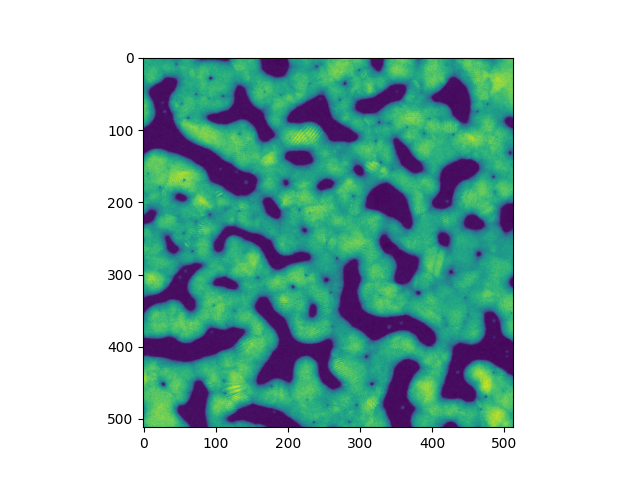

In [6]:
plt.close('all')
# microscope.optics.defocus = -27e-9
print(f"defocus: {microscope.optics.defocus*1.e9:.1f}nm")
print(f"condenser stigmator amplitude: { microscope.optics.stigmators.condenser_stigmator.magnitude():.2f}"+
      f" angle: {microscope.optics.stigmators.condenser_stigmator.angle():.1f}")
microscope.optics.scan_field_of_view  = 200*1e-9
haadf_image = microscope.acquisition.acquire_stem_image(DetectorType.HAADF, 512, 16e-6)# haadf is pixel wise
fig = plt.figure()
im =  plt.imshow(haadf_image.data)

In [20]:
microscope.optics.stigmators.condenser_stigmator.magnitude()

0.001974054938884069

### Focus and Stigmation with OptiSTEM

defocus: -40.6nm


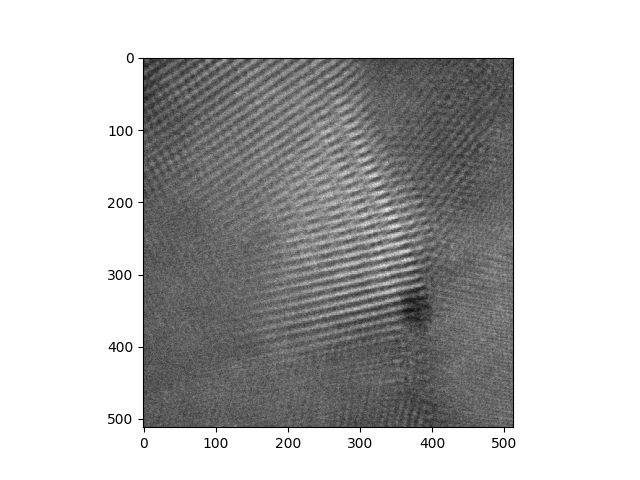

In [9]:
microscope.optics.scan_field_of_view  = 10*1e-9

settings = RunOptiStemSettings(method=OptiStemMethod.C1_A1, dwell_time=2*1e-6, cutoff_in_pixels=5)
microscope.auto_functions.run_opti_stem(settings)
print(f"defocus: {microscope.optics.defocus*1.e9:.1f}nm")
haadf_image = microscope.acquisition.acquire_stem_image(DetectorType.HAADF, 512, 4e-6)# haadf is pixel wise
fig = plt.figure()
im =  plt.imshow(haadf_image.data, cmap='gray')


### Take high resolution Image

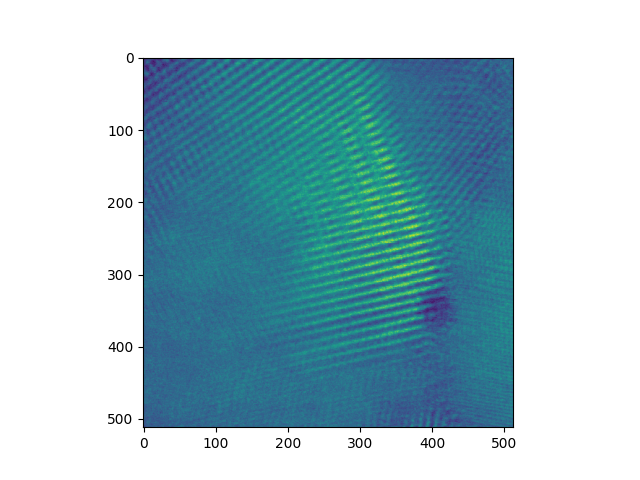

In [10]:
#microscope.optics.defocus = -39e-9
microscope.optics.scan_field_of_view  = 10*1e-9
haadf_image = microscope.acquisition.acquire_stem_image(DetectorType.HAADF, 512, 16e-6)# haadf is pixel wise
fig = plt.figure()
im =  plt.imshow(haadf_image.data)

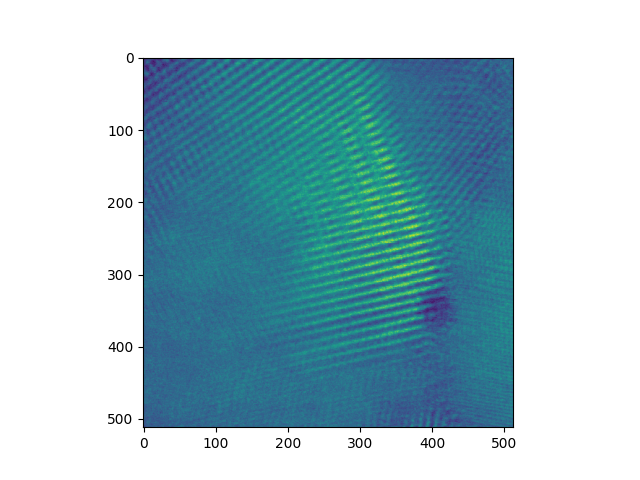

In [13]:

fig = plt.figure()
im =  plt.imshow(haadf_image.data)

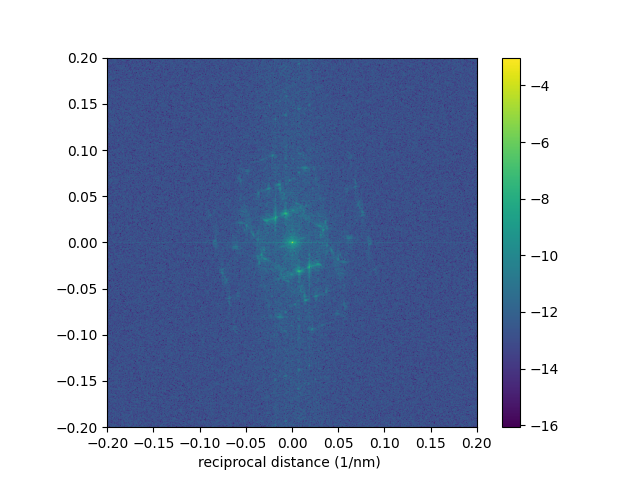

In [40]:
im_fft = np.fft.fftshift(np.fft.fft2(haadf_image.data))
im_fft = np.abs(im_fft)
im_fft /= im_fft.sum()
extent = [-2/10,2/10, -2/10,2/10]

plt.figure()
plt.imshow(np.log(.0000001+np.abs(im_fft)), extent=extent)
axis = 10
plt.xlabel('reciprocal distance (1/nm) ' )
plt.colorbar()

## End Session

In [11]:
#microscope.specimen.stage.absolute_move([0,0, 0])
print(microscope.specimen.stage.position*1e6)
microscope.vacuum.column_valves.close()
print("column valve is: ", microscope.vacuum.column_valves.state)

StagePosition(x=19.482495, y=-12.09846, z=-84.67863, a=90.551)
column valve is:  Closed


## Conclusions

Remote Aberration Correciton is not any faster - Some Machine Learning has to happen - 

but it allows to adopt workflows that work for your microscope
